In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import seasonal_decompose

In [9]:
# Load the dataset
df = pd.read_csv('../../data/january_full.csv')
print("Dataset shape:", df.shape)

Dataset shape: (569504, 11)


In [ ]:
print("Columns:", df.columns)

Columns: Index(['row', 'Unnamed: 0', 'rental_id', 'start_station_id', 'start_station',
       'start_date', 'start_hour', 'end_station_number', 'end_station',
       'end_date', 'end_hour', 'bike_id', 'bike_model', 'total_duration'],
      dtype='object')


In [ ]:
# Removing unwanted columns
df.drop(['row', 'Unnamed: 0'], axis=1, inplace=True)

In [ ]:
print("Columns:", df.columns)
print(df.head())

Columns: Index(['rental_id', 'start_station_id', 'start_station', 'start_date',
       'start_hour', 'end_station_number', 'end_station', 'end_date',
       'end_hour', 'bike_id', 'bike_model', 'total_duration'],
      dtype='object')
   rental_id  start_station_id  \
0  127702739              3425   
1  127702740              3499   
2  127702737            300092   
3  127702738            300029   
4  127702735            300052   

                                       start_station  start_date  start_hour  \
0                       Northington Street , Holborn  2023-01-01          23   
1                 Prince Consort Road, Knightsbridge  2023-01-01          23   
2                    Hertford Road, De Beauvoir Town  2023-01-01          23   
3  Lee Valley VeloPark, Queen Elizabeth Olympic Park  2023-01-01          23   
4               Parsons Green Station, Parsons Green  2023-01-01          23   

   end_station_number                                        end_station  \
0  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569504 entries, 0 to 569503
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   rental_id           569504 non-null  int64 
 1   start_station_id    569504 non-null  int64 
 2   start_station       569504 non-null  object
 3   start_date          569504 non-null  object
 4   start_hour          569504 non-null  int64 
 5   end_station_number  569504 non-null  int64 
 6   end_station         569504 non-null  object
 7   end_date            569504 non-null  object
 8   end_hour            569504 non-null  int64 
 9   bike_id             569504 non-null  int64 
 10  bike_model          569504 non-null  object
 11  total_duration      569504 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 52.1+ MB


In [ ]:
# Basic statistics on duration
duration_stats = df['total_duration'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame()
duration_stats.loc['range'] = duration_stats.loc['max'] - duration_stats.loc['min']
duration_stats.loc['IQR'] = duration_stats.loc['75%'] - duration_stats.loc['25%']
duration_stats.loc['skewness'] = stats.skew(df['total_duration'].dropna())
duration_stats.loc['kurtosis'] = stats.kurtosis(df['total_duration'].dropna())
duration_stats.loc['missing_values'] = df['total_duration'].isna().sum()
duration_stats.loc['missing_percent'] = df['total_duration'].isna().mean() * 100
print("\nDetailed Duration Statistics:")
print(duration_stats)


Detailed Duration Statistics:
                 total_duration
count             569504.000000
mean                  19.186921
std                  181.488876
min                    0.000000
1%                     2.000000
5%                     3.000000
10%                    4.000000
25%                    7.000000
50%                   12.000000
75%                   19.000000
90%                   28.000000
95%                   37.000000
99%                   75.000000
max                37351.000000
range              37351.000000
IQR                   12.000000
skewness              80.255217
kurtosis            8512.202686
missing_values         0.000000
missing_percent        0.000000


In [ ]:
# -------- Distribution Analysis --------
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0, 0.5, 'Frequency')

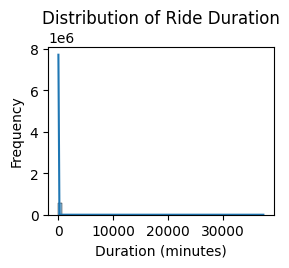

In [ ]:
# Histogram
plt.subplot(2, 2, 1)
sns.histplot(df['total_duration'].dropna(), kde=True, bins=50)
plt.title('Distribution of Ride Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Duration (minutes)')

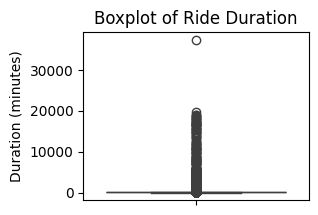

In [ ]:
# Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(y=df['total_duration'].dropna())
plt.title('Boxplot of Ride Duration')
plt.ylabel('Duration (minutes)')

In [ ]:
# Get rental_ids for rides with duration > 10000
rides_above_30000 = df[df['total_duration'] > 30000][['rental_id', 'total_duration']].sort_values('total_duration', ascending=False)
rides_above_20000_to_30000 = df[(df['total_duration'] > 20000) & (df['total_duration'] < 30000)][['rental_id', 'total_duration']].sort_values('total_duration', ascending=False)
print("Rides with duration > 30000 minutes:")
print(rides_above_30000)
print("Rides with duration > 30000 minutes:")
print(rides_above_20000_to_30000)

Rides with duration > 30000 minutes:
        rental_id  total_duration
264265  128064673           37351
Rides with duration > 30000 minutes:
Empty DataFrame
Columns: [rental_id, total_duration]
Index: []


In [ ]:
# Get the row with rental_id = 128064673
target_ride = df[df['rental_id'] == 128064673]
print("\nRide details:")
print(target_ride[['rental_id', 'start_station', 'end_station', 'start_datetime', 'end_datetime', 'total_duration', 'bike_model']])


Ride details:
        rental_id                                      start_station  \
264265  128064673  Lee Valley VeloPark, Queen Elizabeth Olympic Park   

                     end_station      start_datetime        end_datetime  \
264265  Risinghill Street, Angel 2023-01-21 15:00:00 2023-02-16 13:00:00   

        total_duration bike_model  
264265           37351    CLASSIC  


Text(0, 0.5, 'Frequency')

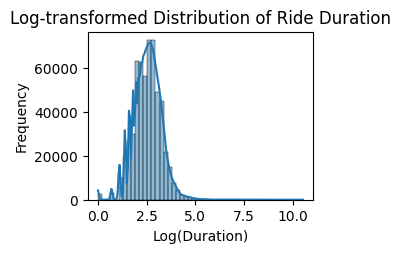

In [ ]:
# Log-transformed histogram for skewed data
plt.subplot(2, 2, 3)
if df['total_duration'].min() <= 0:
    log_duration = np.log1p(df['total_duration'].dropna())  # log(x+1) to handle zeros
else:
    log_duration = np.log(df['total_duration'].dropna())
sns.histplot(log_duration, kde=True, bins=50)
plt.title('Log-transformed Distribution of Ride Duration')
plt.xlabel('Log(Duration)')
plt.ylabel('Frequency')

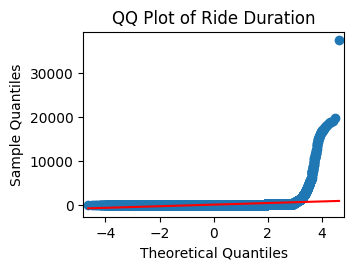

In [ ]:
# QQ plot to check normality
plt.subplot(2, 2, 4)
qqplot(df['total_duration'].dropna(), line='s', ax=plt.gca())
plt.title('QQ Plot of Ride Duration')

plt.tight_layout()
plt.savefig('duration_distribution.png')
plt.show()

In [ ]:
# -------- Outlier Analysis --------
# Calculate Z-scores for outlier detection
z_scores = stats.zscore(df['total_duration'].dropna())
outliers_z = np.abs(z_scores) > 3
outliers_count_z = np.sum(outliers_z)

In [ ]:
# IQR method for outlier detection
Q1 = df['total_duration'].quantile(0.25)
Q3 = df['total_duration'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = (df['total_duration'] < (Q1 - 1.5 * IQR)) | (df['total_duration'] > (Q3 + 1.5 * IQR))
outliers_count_iqr = outliers_iqr.sum()

In [ ]:
print(f"\nOutliers (Z-score method, |z| > 3): {outliers_count_z} ({outliers_count_z/len(df)*100:.2f}%)")
print(f"Outliers (IQR method, outside 1.5*IQR): {outliers_count_iqr} ({outliers_count_iqr/len(df)*100:.2f}%)")


Outliers (Z-score method, |z| > 3): 709 (0.12%)
Outliers (IQR method, outside 1.5*IQR): 27363 (4.80%)


In [ ]:
# Examine extreme values
print("\nTop 10 longest durations:")
print(df.nlargest(10, 'total_duration')[['rental_id', 'start_station', 'end_station', 'total_duration']])
print("\nTop 10 shortest durations:")
print(df.nsmallest(10, 'total_duration')[['rental_id', 'start_station', 'end_station', 'total_duration']])


Top 10 longest durations:
        rental_id                                      start_station  \
264265  128064673  Lee Valley VeloPark, Queen Elizabeth Olympic Park   
279745  128048637                             Maida Vale, Maida Vale   
423537  128187926                        Aldersgate Street, Barbican   
106951  127704500                    Birkenhead Street, King's Cross   
8964    127693305                         Wellington Arch, Hyde Park   
352558  127973573                             Poured Lines, Bankside   
282908  128045386                     Bermondsey Station, Bermondsey   
249088  128080472                        Jubilee Plaza, Canary Wharf   
522132  128279046                             Chesilton Road, Fulham   
435281  128175926                                  East Road, Hoxton   

                           end_station  total_duration  
264265        Risinghill Street, Angel           37351  
279745    North Wharf Road, Paddington           19609  
423537   

In [ ]:
# -------- Duration by Time Analysis --------
# Convert date strings to datetime objects
df['start_datetime'] = pd.to_datetime(df['start_date'] + ' ' + df['start_hour'].astype(str) + ':00:00')
df['end_datetime'] = pd.to_datetime(df['end_date'] + ' ' + df['end_hour'].astype(str) + ':00:00')

In [ ]:
# Extract more time components
df['day_of_week'] = df['start_datetime'].dt.day_name()
df['day_of_month'] = df['start_datetime'].dt.day
df['is_weekend'] = df['start_datetime'].dt.dayofweek >= 5

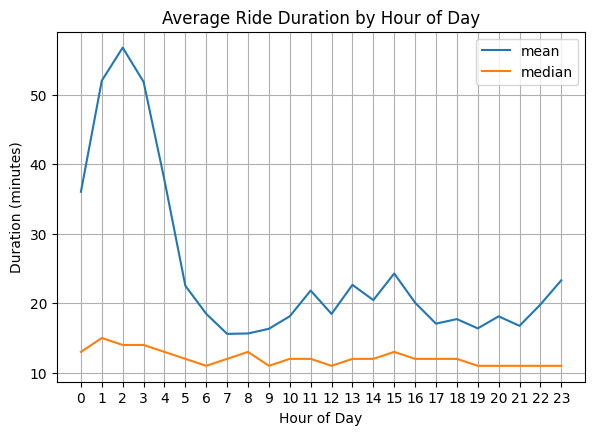

In [ ]:
# Duration by hour of day
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
hourly_duration = df.groupby('start_hour')['total_duration'].agg(['mean', 'median', 'count'])
hourly_duration[['mean', 'median']].plot(ax=plt.gca())
plt.title('Average Ride Duration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Duration (minutes)')
plt.xticks(range(0, 24))
plt.grid(True)


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

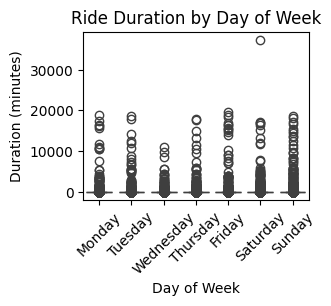

In [ ]:
# Duration by day of week
plt.subplot(2, 2, 2)
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='day_of_week', y='total_duration', data=df, order=order)
plt.title('Ride Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)


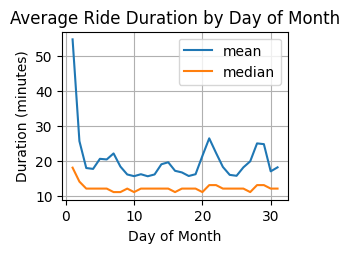

In [ ]:
# Duration by day of month
plt.subplot(2, 2, 3)
daily_duration = df.groupby('day_of_month')['total_duration'].agg(['mean', 'median', 'count'])
daily_duration[['mean', 'median']].plot(ax=plt.gca())
plt.title('Average Ride Duration by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Duration (minutes)')
plt.grid(True)

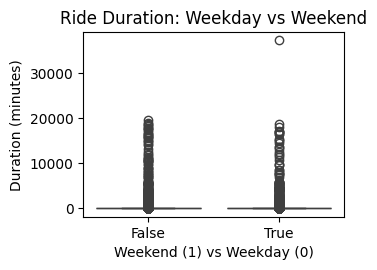

In [ ]:
# Weekday vs Weekend
plt.subplot(2, 2, 4)
sns.boxplot(x='is_weekend', y='total_duration', data=df)
plt.title('Ride Duration: Weekday vs Weekend')
plt.xlabel('Weekend (1) vs Weekday (0)')
plt.ylabel('Duration (minutes)')

plt.tight_layout()
plt.savefig('duration_by_time.png')
plt.show()

In [ ]:
# -------- Duration by Bike Model Analysis --------
if 'bike_model' in df.columns:
    plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

Text(0, 0.5, 'Duration (minutes)')

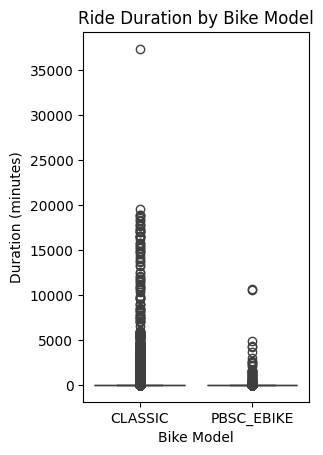

In [ ]:
# Distribution by bike model
plt.subplot(1, 2, 1)
sns.boxplot(x='bike_model', y='total_duration', data=df)
plt.title('Ride Duration by Bike Model')
plt.xlabel('Bike Model')
plt.ylabel('Duration (minutes)')

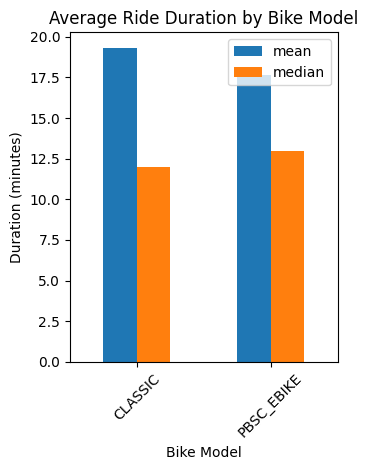


Duration Statistics by Bike Model:
                 mean  median   count
bike_model                           
CLASSIC     19.308623    12.0  527776
PBSC_EBIKE  17.647623    13.0   41728


In [ ]:
# Mean and median by bike model
plt.subplot(1, 2, 2)
model_duration = df.groupby('bike_model')['total_duration'].agg(['mean', 'median', 'count'])
model_duration[['mean', 'median']].plot(kind='bar', ax=plt.gca())
plt.title('Average Ride Duration by Bike Model')
plt.xlabel('Bike Model')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
    
plt.tight_layout()
plt.savefig('duration_by_bike_model.png')
plt.show()
    
print("\nDuration Statistics by Bike Model:")
print(model_duration)

In [ ]:
# -------- Duration by Station Analysis --------
# Top 10 start stations by average duration
top_start_stations = df.groupby('start_station')['total_duration'].agg(['mean', 'median', 'count'])
top_start_stations = top_start_stations[top_start_stations['count'] > 10].sort_values('mean', ascending=False).head(10)

In [ ]:
# Top 10 end stations by average duration
top_end_stations = df.groupby('end_station')['total_duration'].agg(['mean', 'median', 'count'])
top_end_stations = top_end_stations[top_end_stations['count'] > 10].sort_values('mean', ascending=False).head(10)

In [ ]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

Text(0, 0.5, 'Station')

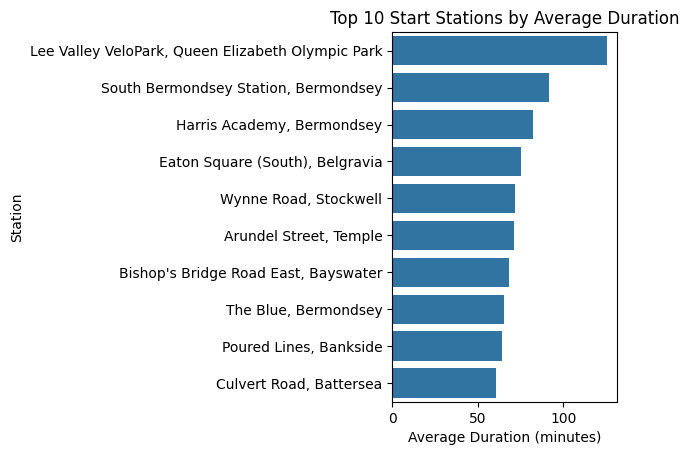

In [ ]:
plt.subplot(1, 2, 1)
sns.barplot(x=top_start_stations['mean'].values, y=top_start_stations.index, orient='h')
plt.title('Top 10 Start Stations by Average Duration')
plt.xlabel('Average Duration (minutes)')
plt.ylabel('Station')

Text(0, 0.5, 'Station')

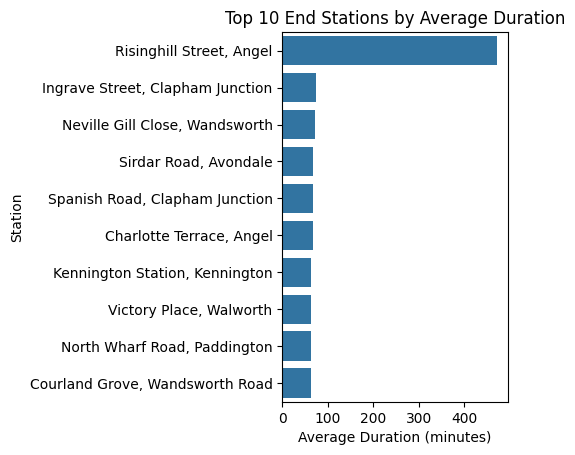

In [ ]:
plt.subplot(1, 2, 2)
sns.barplot(x=top_end_stations['mean'].values, y=top_end_stations.index, orient='h')
plt.title('Top 10 End Stations by Average Duration')
plt.xlabel('Average Duration (minutes)')
plt.ylabel('Station')


In [ ]:
plt.tight_layout()
plt.savefig('duration_by_station.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print("\nTop 10 Start Stations by Average Duration:")
print(top_start_stations)
print("\nTop 10 End Stations by Average Duration:")
print(top_end_stations)


Top 10 Start Stations by Average Duration:
                                                         mean  median  count
start_station                                                               
Lee Valley VeloPark, Queen Elizabeth Olympic Park  125.368272    13.0    353
South Bermondsey Station, Bermondsey                91.516393    20.0    244
Harris Academy, Bermondsey                          82.422819    15.0    298
Eaton Square (South), Belgravia                     75.284722    11.5    288
Wynne Road, Stockwell                               72.045267    19.0    243
Arundel Street, Temple                              71.460317    15.0    315
Bishop's Bridge Road East, Bayswater                68.146417    14.0    321
The Blue, Bermondsey                                65.422907    21.0    227
Poured Lines, Bankside                              64.131443    12.0    388
Culvert Road, Battersea                             60.416446    10.0    377

Top 10 End Stations by Average 

In [ ]:
# -------- Time Series Analysis of Duration --------
# Daily average duration
daily_avg = df.groupby(df['start_datetime'].dt.date)['total_duration'].mean()
daily_series = pd.Series(daily_avg)


In [ ]:
# Plot the time series
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

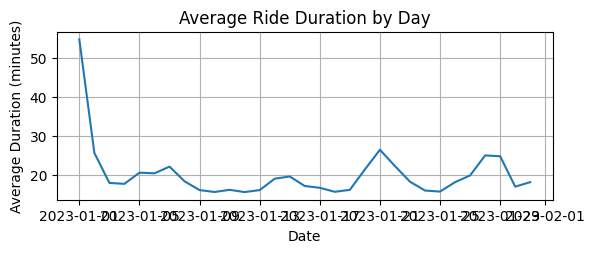

In [ ]:
plt.subplot(2, 1, 1)
plt.plot(daily_series.index, daily_series.values)
plt.title('Average Ride Duration by Day')
plt.xlabel('Date')
plt.ylabel('Average Duration (minutes)')
plt.grid(True)

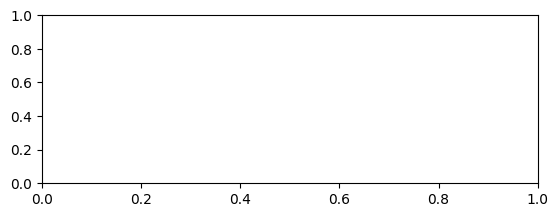

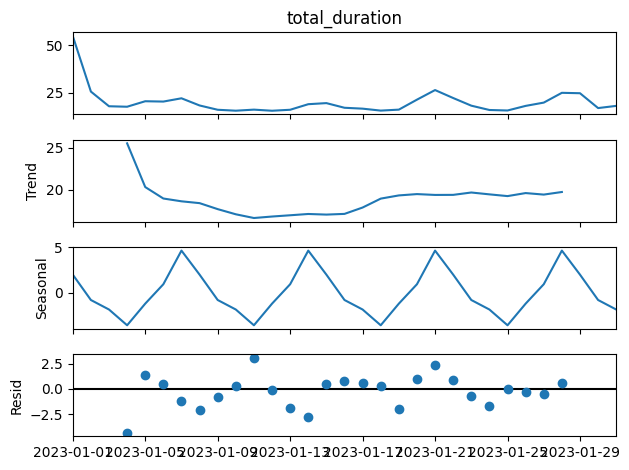

In [ ]:
# If we have enough data, perform seasonal decomposition
if len(daily_series) > 7:
    try:
        plt.subplot(2, 1, 2)
        decomposition = seasonal_decompose(daily_series, model='additive', period=7)
        decomposition.plot()
        plt.tight_layout()
    except:
        plt.subplot(2, 1, 2)
        plt.text(0.5, 0.5, 'Seasonal decomposition requires more data points', 
                 horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('duration_time_series.png')
plt.show()


In [ ]:
# -------- Additional Statistical Tests --------
# Test for normality
shapiro_test = stats.shapiro(df['total_duration'].dropna().sample(min(5000, len(df))))
print("\nShapiro-Wilk Test for Normality:")
print(f"W={shapiro_test[0]:.4f}, p-value={shapiro_test[1]:.10f}")
if shapiro_test[1] < 0.05:
    print("The duration distribution is not normal (p < 0.05)")
else:
    print("The duration distribution appears to be normal (p >= 0.05)")


Shapiro-Wilk Test for Normality:
W=0.0477, p-value=0.0000000000
The duration distribution is not normal (p < 0.05)


In [ ]:
# Test for differences between weekday and weekend durations
weekday_durations = df[~df['is_weekend']]['total_duration'].dropna()
weekend_durations = df[df['is_weekend']]['total_duration'].dropna()

if len(weekday_durations) > 0 and len(weekend_durations) > 0:
    mann_whitney = stats.mannwhitneyu(weekday_durations, weekend_durations)
    print("\nMann-Whitney U Test (Weekday vs Weekend Durations):")
    print(f"U={mann_whitney[0]:.4f}, p-value={mann_whitney[1]:.10f}")
    if mann_whitney[1] < 0.05:
        print("There is a significant difference between weekday and weekend durations (p < 0.05)")
    else:
        print("No significant difference between weekday and weekend durations (p >= 0.05)")



Mann-Whitney U Test (Weekday vs Weekend Durations):
U=25836582587.5000, p-value=0.0000000000
There is a significant difference between weekday and weekend durations (p < 0.05)


In [ ]:
# -------- Duration Categories --------
# Create duration categories for analysis
duration_bins = [0, 5, 10, 15, 30, 60, 120, df['total_duration'].max()]
duration_labels = ['Very Short (0-5)', 'Short (5-10)', 'Medium (10-15)', 'Normal (15-30)', 
                  'Long (30-60)', 'Very Long (60-120)', f'Extended (>120)']
df['duration_category'] = pd.cut(df['total_duration'], bins=duration_bins, labels=duration_labels)

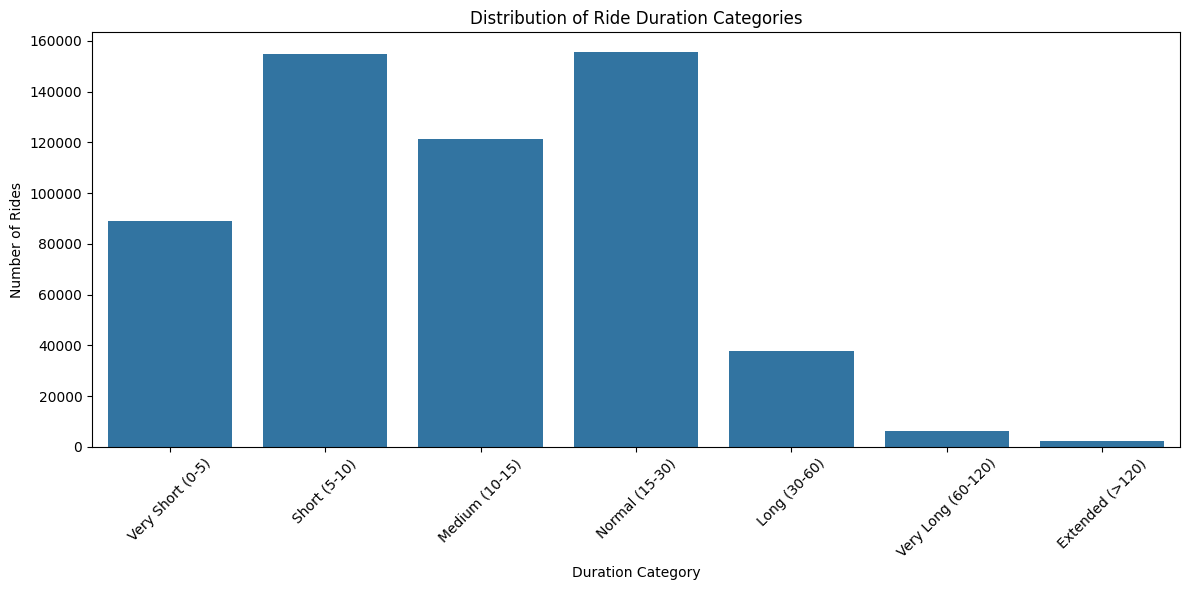

In [ ]:
# Plot the distribution of duration categories
plt.figure(figsize=(12, 6))
category_counts = df['duration_category'].value_counts().sort_index()
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Distribution of Ride Duration Categories')
plt.xlabel('Duration Category')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('duration_categories.png')
plt.show()

In [ ]:
print("\nDuration Categories Distribution:")
print(category_counts)
print(f"Percentage: {(category_counts / len(df) * 100).round(2)}")


Duration Categories Distribution:
duration_category
Very Short (0-5)       89183
Short (5-10)          154915
Medium (10-15)        121193
Normal (15-30)        155597
Long (30-60)           37615
Very Long (60-120)      6061
Extended (>120)         2401
Name: count, dtype: int64
Percentage: duration_category
Very Short (0-5)      15.66
Short (5-10)          27.20
Medium (10-15)        21.28
Normal (15-30)        27.32
Long (30-60)           6.60
Very Long (60-120)     1.06
Extended (>120)        0.42
Name: count, dtype: float64



Correlations with Duration:
total_duration        1.000000
start_station_id      0.004014
end_station_number    0.001831
end_hour             -0.003408
rental_id            -0.004311
day_of_month         -0.005234
start_hour           -0.006620
bike_id              -0.011393
Name: total_duration, dtype: float64


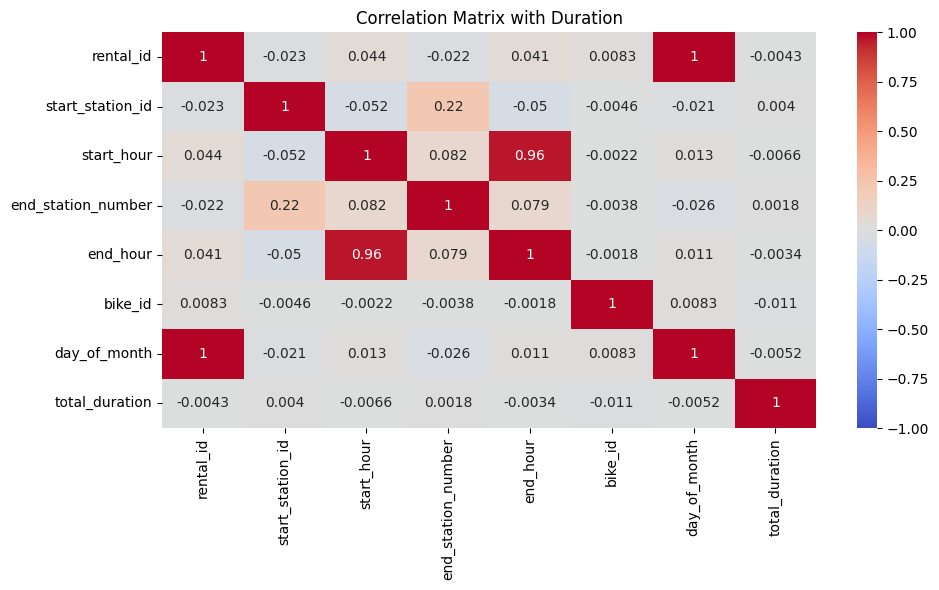

In [ ]:
# -------- Correlation Analysis --------
# If there are numeric variables that might correlate with duration, analyze them
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1 and 'total_duration' in numeric_cols:
    numeric_cols.remove('total_duration')
    
    if numeric_cols:
        correlations = df[numeric_cols + ['total_duration']].corr()['total_duration'].sort_values(ascending=False)
        print("\nCorrelations with Duration:")
        print(correlations)
        
        plt.figure(figsize=(10, 6))
        sns.heatmap(df[numeric_cols + ['total_duration']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Correlation Matrix with Duration')
        plt.tight_layout()
        plt.savefig('duration_correlations.png')
        plt.show()

In [ ]:
# -------- Summary and Recommendations --------
print(f"Total rides analyzed: {len(df)}")
print(f"Average duration: {df['total_duration'].mean():.2f} minutes")
print(f"Median duration: {df['total_duration'].median():.2f} minutes")
print(f"Most common duration category: {df['duration_category'].value_counts().index[0]}")
print(f"Percentage of outliers (IQR method): {outliers_count_iqr/len(df)*100:.2f}%")

if df['total_duration'].skew() > 1:
    print("The distribution is positively skewed (many short rides, fewer long rides)")
elif df['total_duration'].skew() < -1:
    print("The distribution is negatively skewed (many long rides, fewer short rides)")
else:
    print("The distribution is relatively symmetric")



===== DURATION ANALYSIS SUMMARY =====
Total rides analyzed: 569504
Average duration: 19.19 minutes
Median duration: 12.00 minutes
Most common duration category: Normal (15-30)
Percentage of outliers (IQR method): 4.80%
The distribution is positively skewed (many short rides, fewer long rides)


In [ ]:
# -------- Export Results --------
# Export summary statistics to CSV
duration_stats.to_csv('data/duration_statistics.csv')

# Export processed data with new features if needed
df.to_csv('data/bike_rentals_january_processed.csv', index=False)


Analysis complete. Visualizations and statistics files have been saved.
